# Clustering

____
## 1. Chuẩn bị vấn đề

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/3_model/featured_data.csv")

____
## 2. Xử lý giá trị ngoại lai

### 2.1 Chọn cột dữ liệu

In [3]:
df = df.rename(columns={
    "delivered_orders": "frequency",
    "recency_days": "recency"
})

df = df[["customer_unique_id", "recency", "frequency", "monetary"]]
df = df[df["frequency"] > 0]

### 2.2 Nhận xét dữ liệu RFM

#### Histogram

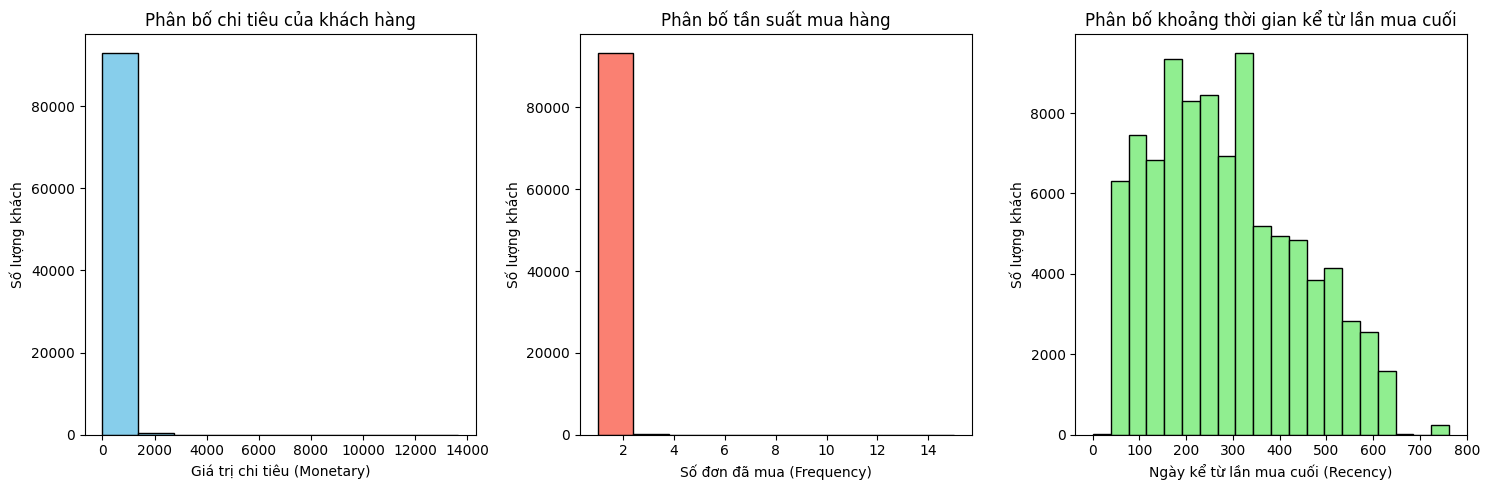

In [4]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)  # 1 hàng 3 cột, vị trí 1
plt.hist(df["monetary"], bins=10, color='skyblue', edgecolor='black')
plt.title("Phân bố chi tiêu của khách hàng")
plt.xlabel("Giá trị chi tiêu (Monetary)")
plt.ylabel("Số lượng khách")

plt.subplot(1, 3, 2)  # 1 hàng 3 cột, vị trí 2
plt.hist(df["frequency"], bins=10, color='salmon', edgecolor='black')
plt.title("Phân bố tần suất mua hàng")
plt.xlabel("Số đơn đã mua (Frequency)")
plt.ylabel("Số lượng khách")

plt.subplot(1, 3, 3)  # 1 hàng 3 cột, vị trí 3
plt.hist(df["recency"], bins=20, color='lightgreen', edgecolor='black')
plt.title("Phân bố khoảng thời gian kể từ lần mua cuối")
plt.xlabel("Ngày kể từ lần mua cuối (Recency)")
plt.ylabel("Số lượng khách")

plt.tight_layout()
plt.show();

**Nhận xét:**
- Có xuất hiện các giá trị ngoại lai ở Monetary và Frequency

#### Boxplot

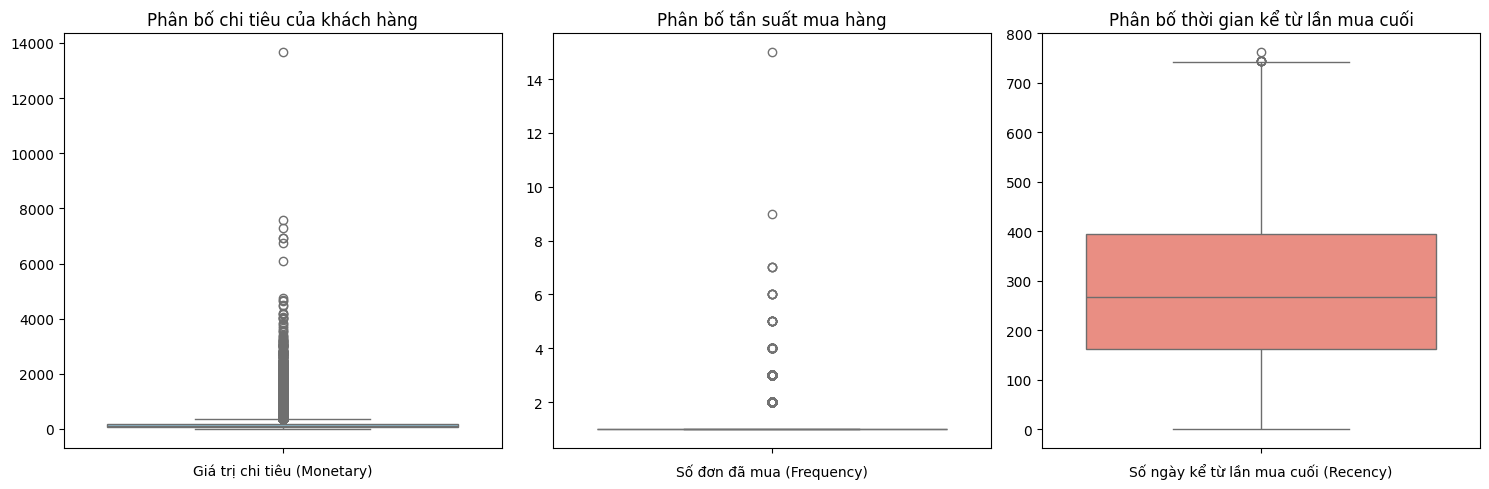

In [5]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)  # 1 hàng 3 cột, vị trí 1
sns.boxplot(df["monetary"], color='skyblue')
plt.title("Phân bố chi tiêu của khách hàng")
plt.xlabel("Giá trị chi tiêu (Monetary)")
plt.ylabel("") 

plt.subplot(1, 3, 2)  # 1 hàng 3 cột, vị trí 2
sns.boxplot(df["frequency"], color='lightgreen')
plt.title("Phân bố tần suất mua hàng")
plt.xlabel("Số đơn đã mua (Frequency)")
plt.ylabel("") 

plt.subplot(1, 3, 3)  # 1 hàng 3 cột, vị trí 3
sns.boxplot(df["recency"], color='salmon')
plt.title("Phân bố thời gian kể từ lần mua cuối")
plt.xlabel("Số ngày kể từ lần mua cuối (Recency)")
plt.ylabel("") 

plt.tight_layout()
plt.show()

**Nhận xét:**
- Monetary và Frequency không ổn cần lưu ý các giá trị ngoại lai
- Recency đã hợp lý

### 2.3 Tách dữ liệu có outlier và non-outlier

In [6]:
df.describe()

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,286.416654,1.033420,165.197003
std,152.588939,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,163.000000,1.000000,63.052500
50%,267.000000,1.000000,107.780000
75%,395.000000,1.000000,182.557500
max,762.000000,15.000000,13664.080000


In [7]:
df["frequency"].value_counts()

frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

#### 2.3.1 RFM có giá trị ngoại lai

In [8]:
M_Q1 = df["monetary"].quantile(0.25)
M_Q3 = df["monetary"].quantile(0.75)
M_IQR = M_Q3 - M_Q1


# Lấy outliers
monetary_outliers_df = df[(df["monetary"] < (M_Q1 - 1.5 * M_IQR)) | ((df["monetary"] > (M_Q3 + 1.5 * M_IQR)))].copy()
monetary_outliers_df.describe()

,recency,frequency,monetary
count,7402.000000,7402.000000,7402.000000
mean,285.587949,1.121454,708.580775
std,154.790289,0.463477,509.493414
min,48.000000,1.000000,361.820000
25%,159.000000,1.000000,420.865000
50%,263.000000,1.000000,548.140000
75%,394.000000,1.000000,793.090000
max,743.000000,15.000000,13664.080000


In [9]:
F_Q1 = df["frequency"].quantile(0.25)
F_Q3 = df["frequency"].quantile(0.75)
F_IQR = F_Q3 - F_Q1


# Lấy outliers
frequency_outliers_df = df[(df["frequency"] < (F_Q1 - 1.5 * F_IQR)) | ((df["frequency"] > (F_Q3 + 1.5 * F_IQR)))].copy()
frequency_outliers_df.describe()

,recency,frequency,monetary
count,2801.000000,2801.000000,2801.000000
mean,268.677258,2.113888,308.588793
std,143.668321,0.503796,316.979193
min,50.000000,2.000000,35.940000
25%,154.000000,2.000000,147.130000
50%,248.000000,2.000000,225.550000
75%,365.000000,2.000000,361.020000
max,740.000000,15.000000,7571.630000


In [10]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

# Lấy dữ liệu trùng cả 2 nhóm
outliers_df = monetary_outliers_df.loc[overlap_indices]
outliers_df

,customer_unique_id,recency,frequency,monetary
1,da122df9eeddfedc1dc1f5349a1a690c,564,2,7571.63
9,c8460e4251689ba205045f3ea17884a1,70,4,4655.91
24,59d66d72939bc9497e19d89c61a96d5f,433,2,3559.99
61,eae0a83d752b1dd32697e0e7b4221656,176,2,2783.01
90,d77aa95864ae5b42160937615628723a,414,2,2450.10
...,...,...,...,...
7354,3d50a44231c2a153219cef76ee3e445d,237,2,363.26
7374,e58e049eea2419a34274619f798d0cd4,323,2,362.89
7375,1650819cd492bbf4b9d189c7d4126475,271,2,362.84
7378,a4e8a2fb3d4d783c8eec5bf1ea80d3c6,213,2,362.78


In [11]:
outliers_df.describe()

,recency,frequency,monetary
count,698.000000,698.000000,698.000000
mean,257.540115,2.287966,659.380258
std,139.181278,0.881110,469.628762
min,52.000000,2.000000,362.100000
25%,150.000000,2.000000,424.650000
50%,235.000000,2.000000,514.580000
75%,351.750000,2.000000,729.292500
max,739.000000,15.000000,7571.630000


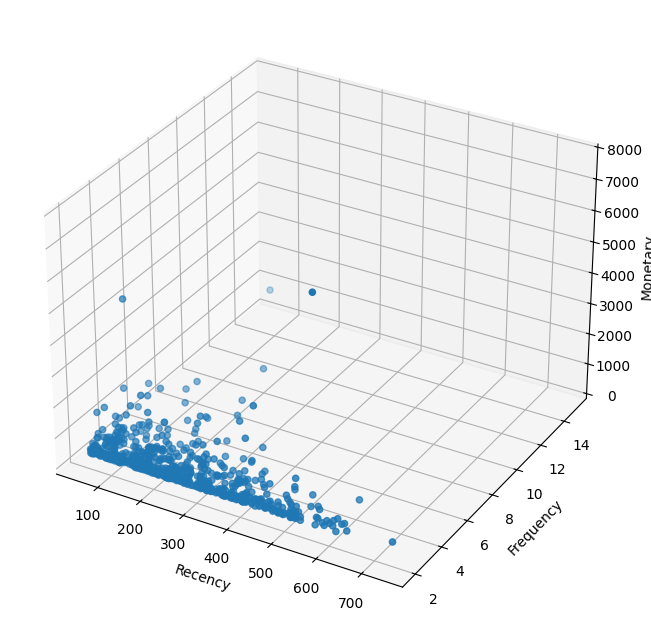

In [12]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    outliers_df["recency"],
    outliers_df["frequency"],
    outliers_df["monetary"],
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary') 

plt.show();

#### 2.3.2 RFM **không** có giá trị ngoại lai

In [13]:
non_outliers_df = df[(~df.index.isin(monetary_outliers_df.index)) & (~df.index.isin(frequency_outliers_df.index))]
non_outliers_df

,customer_unique_id,recency,frequency,monetary
7402,59de1c72ff3794305a1495454f6a942d,485,1,361.76
7404,050edcc983b8b15a8c076355d0a784bd,345,1,361.64
7405,3204cb18b0f18464319d17a3076fb5fc,405,1,361.62
7406,211e942aae3695180382d77ed1dde7e9,622,1,361.50
7407,aa24ca14216f7cf7d2b319932297a0e1,250,1,361.47
...,...,...,...,...
93353,6f5b9d1cdccc4d28f0483a612edecacf,410,1,11.63
93354,b33336f46234b24a613ad9064d13106d,118,1,10.89
93355,bd06ce0e06ad77a7f681f1a4960a3cc6,399,1,10.07
93356,317cfc692e3f86c45c95697c61c853a6,53,1,9.59


In [14]:
non_outliers_df.describe()

,recency,frequency,monetary
count,83853.000000,83853.0,83853.000000
mean,286.841997,1.0,116.554412
std,152.564276,0.0,74.202053
min,1.000000,1.0,0.000000
25%,163.000000,1.0,58.950000
50%,268.000000,1.0,97.810000
75%,396.000000,1.0,157.200000
max,762.000000,1.0,361.760000


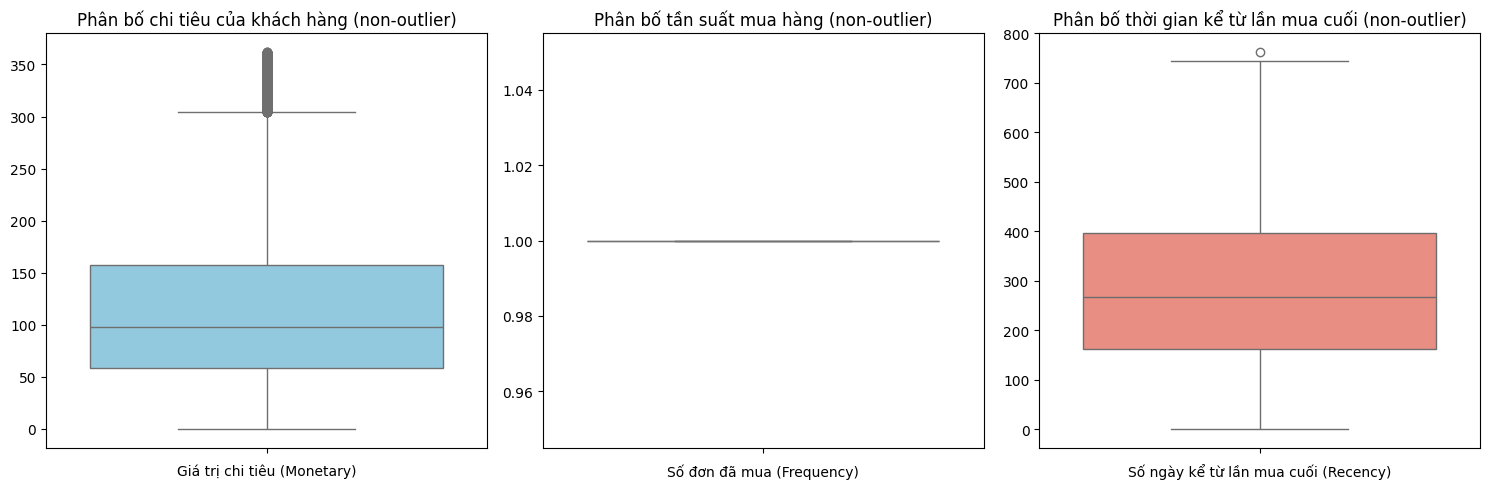

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)  # 1 hàng 3 cột, vị trí 1
sns.boxplot(non_outliers_df["monetary"], color='skyblue')
plt.title("Phân bố chi tiêu của khách hàng (non-outlier)")
plt.xlabel("Giá trị chi tiêu (Monetary)")
plt.ylabel("")

plt.subplot(1, 3, 2)  # 1 hàng 3 cột, vị trí 2
sns.boxplot(non_outliers_df["frequency"], color='lightgreen')
plt.title("Phân bố tần suất mua hàng (non-outlier)")
plt.xlabel("Số đơn đã mua (Frequency)")
plt.ylabel("")

plt.subplot(1, 3, 3)  # 1 hàng 3 cột, vị trí 3
sns.boxplot(non_outliers_df["recency"], color='salmon')
plt.title("Phân bố thời gian kể từ lần mua cuối (non-outlier)")
plt.xlabel("Số ngày kể từ lần mua cuối (Recency)")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [16]:
print(non_outliers_df["frequency"].value_counts())
print()
print(df["frequency"].value_counts())

frequency
1    83853
Name: count, dtype: int64

frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


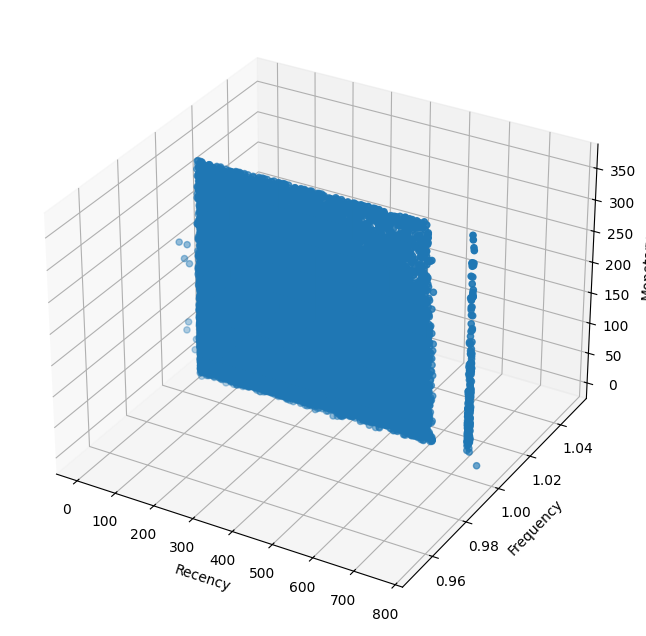

In [17]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    non_outliers_df["recency"],
    non_outliers_df["frequency"],
    non_outliers_df["monetary"],
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary') 

plt.show();

**Nhận xét**
- Hầu như khách chỉ mua hàng 1 lần

____
## 3. Scale lại dữ liệu

In [18]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[["recency", "frequency", "monetary"]])

In [19]:
scaled_data_df = pd.DataFrame(scaled_data, columns=["recency", "frequency", "monetary"])
scaled_data_df

,recency,frequency,monetary
0,1.298857,0.0,3.304586
1,0.381206,0.0,3.302969
2,0.774485,0.0,3.302699
3,2.196845,0.0,3.301082
4,-0.241487,0.0,3.300678
...,...,...,...
83848,0.807258,0.0,-1.414045
83849,-1.106701,0.0,-1.424018
83850,0.735157,0.0,-1.435069
83851,-1.532753,0.0,-1.441538


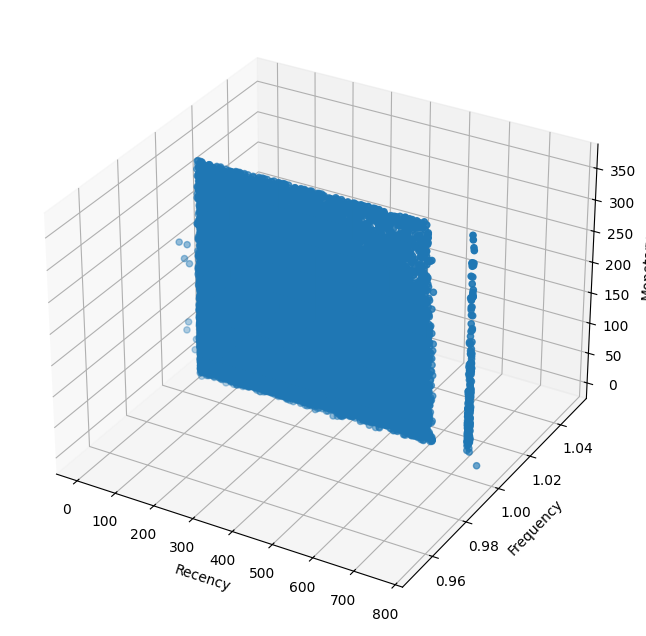

In [20]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    non_outliers_df["recency"],
    non_outliers_df["frequency"],
    non_outliers_df["monetary"],
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary') 

plt.show();

**Nhận xét:**
- Không có sự phân bố về dữ liệu

____
## 4. K-Mean Clustering

In [21]:
max_k = 12
silhouette_scores = []
inertia = []
k_values = range(2, max_k + 1)

for k in k_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2000, max_iter=500)
    cluster_label = kmeans.fit_predict(scaled_data_df)
    
    # Chỉ tính silhouette trên 5000 mẫu ngẫu nhiên để giảm thời gian
    sample_idx = np.random.choice(len(scaled_data_df), 5000, replace=False)
    sil_score = silhouette_score(scaled_data_df.iloc[sample_idx], cluster_label[sample_idx])
    
    silhouette_scores.append(sil_score)
    inertia.append(kmeans.inertia_)

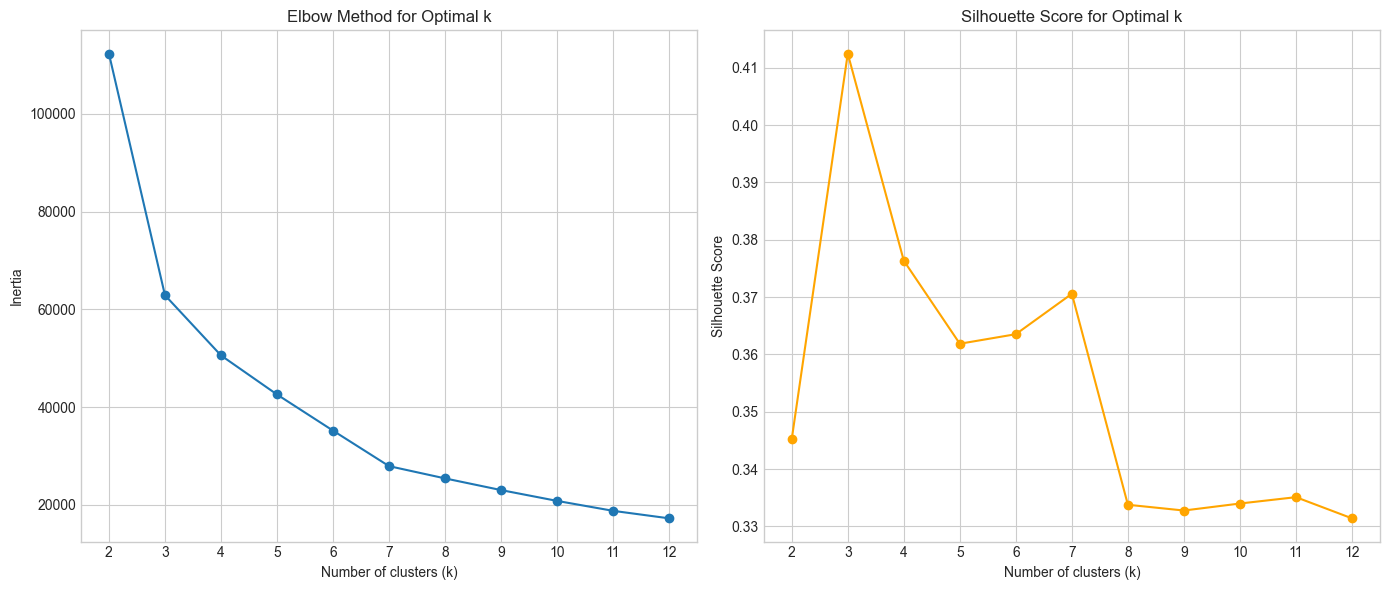

In [35]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values) # Hiển thị đủ giá trị trên trục x
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values) # Hiển thị đủ giá trị trên trục x
plt.grid(True)


plt.tight_layout()
plt.show();

Nên chọn $k=\mathbf{3}$.

$k=3$ là điểm khuỷu tay tốt nhất theo Inertia.

$k=3$ mang lại điểm Silhouette cao nhất.

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42, max_iter=1000)

cluster_labels = kmeans.fit_predict(scaled_data_df)

cluster_labels

array([2, 2, 2, ..., 1, 0, 1], shape=(83853,), dtype=int32)

In [24]:
non_outliers_df["Cluster"] = cluster_labels
non_outliers_df

C:\Users\sonvuuu\AppData\Local\Temp\ipykernel_9020\1071184375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df["Cluster"] = cluster_labels


,customer_unique_id,recency,frequency,monetary,Cluster
7402,59de1c72ff3794305a1495454f6a942d,485,1,361.76,2
7404,050edcc983b8b15a8c076355d0a784bd,345,1,361.64,2
7405,3204cb18b0f18464319d17a3076fb5fc,405,1,361.62,2
7406,211e942aae3695180382d77ed1dde7e9,622,1,361.50,2
7407,aa24ca14216f7cf7d2b319932297a0e1,250,1,361.47,2
...,...,...,...,...,...
93353,6f5b9d1cdccc4d28f0483a612edecacf,410,1,11.63,1
93354,b33336f46234b24a613ad9064d13106d,118,1,10.89,0
93355,bd06ce0e06ad77a7f681f1a4960a3cc6,399,1,10.07,1
93356,317cfc692e3f86c45c95697c61c853a6,53,1,9.59,0


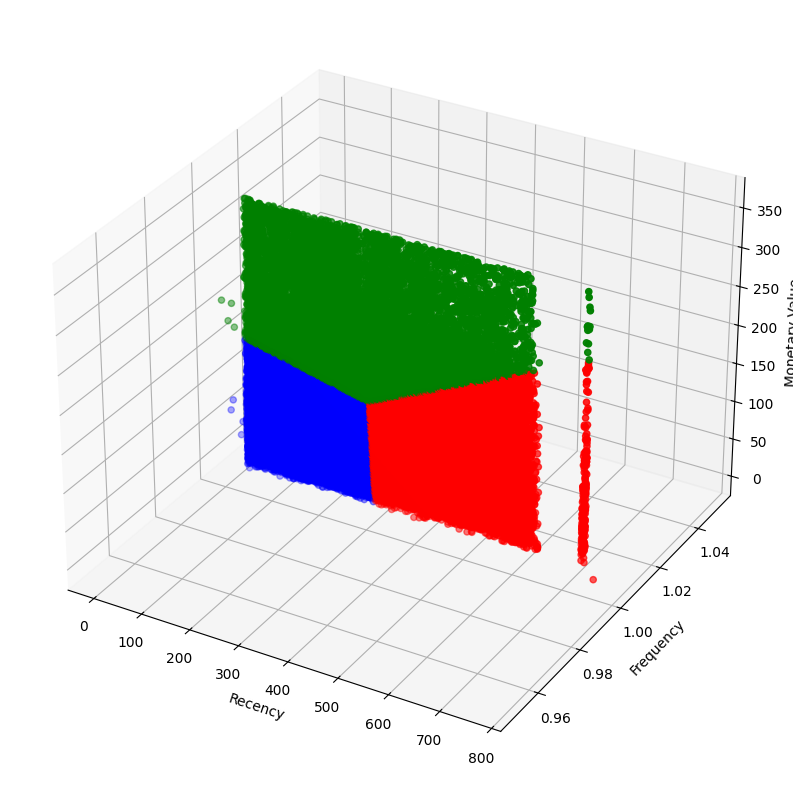

In [25]:
cluster_colors = {
    0: 'blue',
    1: 'red',
    2: 'green',
}

colors = non_outliers_df["Cluster"].map(cluster_colors)

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    non_outliers_df["recency"],
    non_outliers_df["frequency"],
    non_outliers_df["monetary"],
    c = colors,
    marker='o'
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value') 

plt.show();

____
## 5. Phân tích dữ liệu sau khi phân cụm

###  5.1 Dữ liệu không ngoại lai

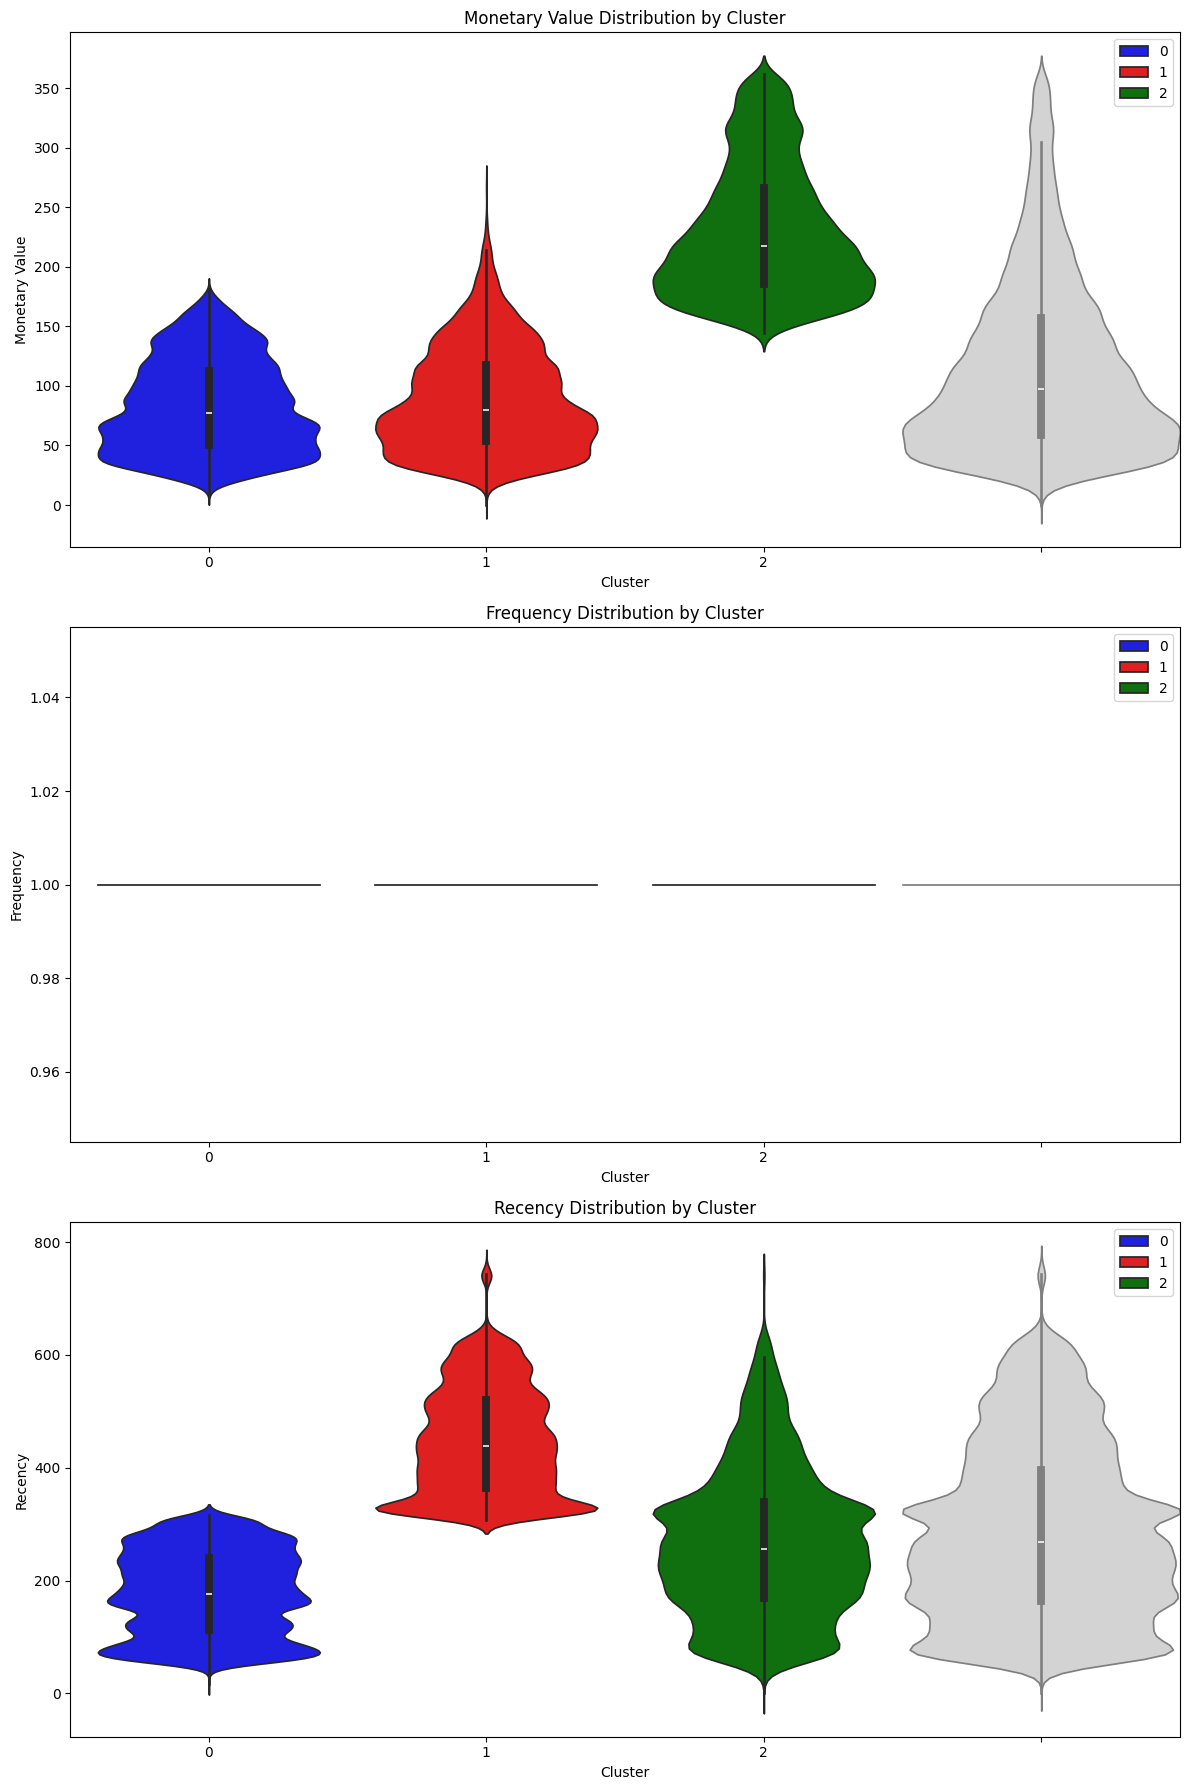

In [26]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df["Cluster"], y=non_outliers_df["monetary"], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df["monetary"], color='lightgray', width=1.0) # violinplot tổng thể
plt.title("Monetary Value Distribution by Cluster")
plt.ylabel("Monetary Value")
plt.xlabel("Cluster")

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df["Cluster"], y=non_outliers_df["frequency"], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df["frequency"], color='lightgray', width=1.0)
plt.title("Frequency Distribution by Cluster")
plt.ylabel("Frequency")

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df["Cluster"], y=non_outliers_df["recency"], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df["recency"], color='lightgray', width=1.0)
plt.title("Recency Distribution by Cluster")
plt.ylabel("Recency")


plt.tight_layout()
plt.show();

#### 🟦 Nhóm 1 – "Nurture"
- **Ý nghĩa:** Cụm này là những khách hàng vừa mới mua hàng (Recency thấp) nhưng giá trị đơn hàng không cao và cũng không thường xuyên mua hàng.  
- **Hành động:** Tập trung xây dựng mối quan hệ với khách hàng, cung cấp dịch vụ khách hàng tốt và khuyến mãi để khuyến khích mua thường xuyên hơn.

---

#### 🟥 Nhóm 2 – "Re-engage"
- **Ý nghĩa:** Cụm này là những khách hàng chi tiêu trung bình thấp và đã không mua hàng trong một thời gian dài (Recency cao), cũng không thường xuyên mua hàng. Đây là nhóm có nguy cơ rời bỏ.  
- **Hành động:** Sử dụng chiến dịch marketing và ưu đãi giảm giá đặc biệt để thu hút họ quay lại.

---

#### 🟩 Nhóm 3 – "Develop"
- **Ý nghĩa:** Đây là nhóm khách hàng chi tiêu trung bình cao và mới mua hàng gần đây, dù không mua thường xuyên. Họ đã bộc lộ giá trị, nhưng mức độ gắn kết vẫn đang ở giai đoạn đầu.
- **Hành động:** Kích thích lần mua thứ 2–3 thông qua tặng kèm sản phẩm và gợi ý sản phẩm liên quan, kết hợp ưu đãi cá nhân hóa và truyền thông giá trị sản phẩm để xây dựng niềm tin và thúc đẩy khách quay lại.


###  5.2 Dữ liệu ngoại lai

In [27]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

# Lấy dữ liệu trùng cả 2 nhóm
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

# Sau đó loại bỏ khỏi 2 nhóm riêng
monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])
outlier_clusters_df

,customer_unique_id,recency,frequency,monetary,Cluster
0,0a0a92112bd4c708ca5fde585afaa872,383,1,13664.08,-1
2,763c8b1c9c68a0229c42c9fc6f662b93,94,1,7274.88,-1
3,dc4802a71eae9be1dd28f5d788ceb526,612,1,6929.31,-1
4,459bef486812aa25204be022145caa62,84,1,6922.21,-1
5,ff4159b92c40ebe40454e3e6a7c35ed6,511,1,6726.66,-1
...,...,...,...,...,...
7354,3d50a44231c2a153219cef76ee3e445d,237,2,363.26,-3
7374,e58e049eea2419a34274619f798d0cd4,323,2,362.89,-3
7375,1650819cd492bbf4b9d189c7d4126475,271,2,362.84,-3
7378,a4e8a2fb3d4d783c8eec5bf1ea80d3c6,213,2,362.78,-3


In [28]:
print(len(monetary_and_frequency_outliers))
print(len(monetary_only_outliers))
print(len(frequency_only_outliers))

698
6704
2103


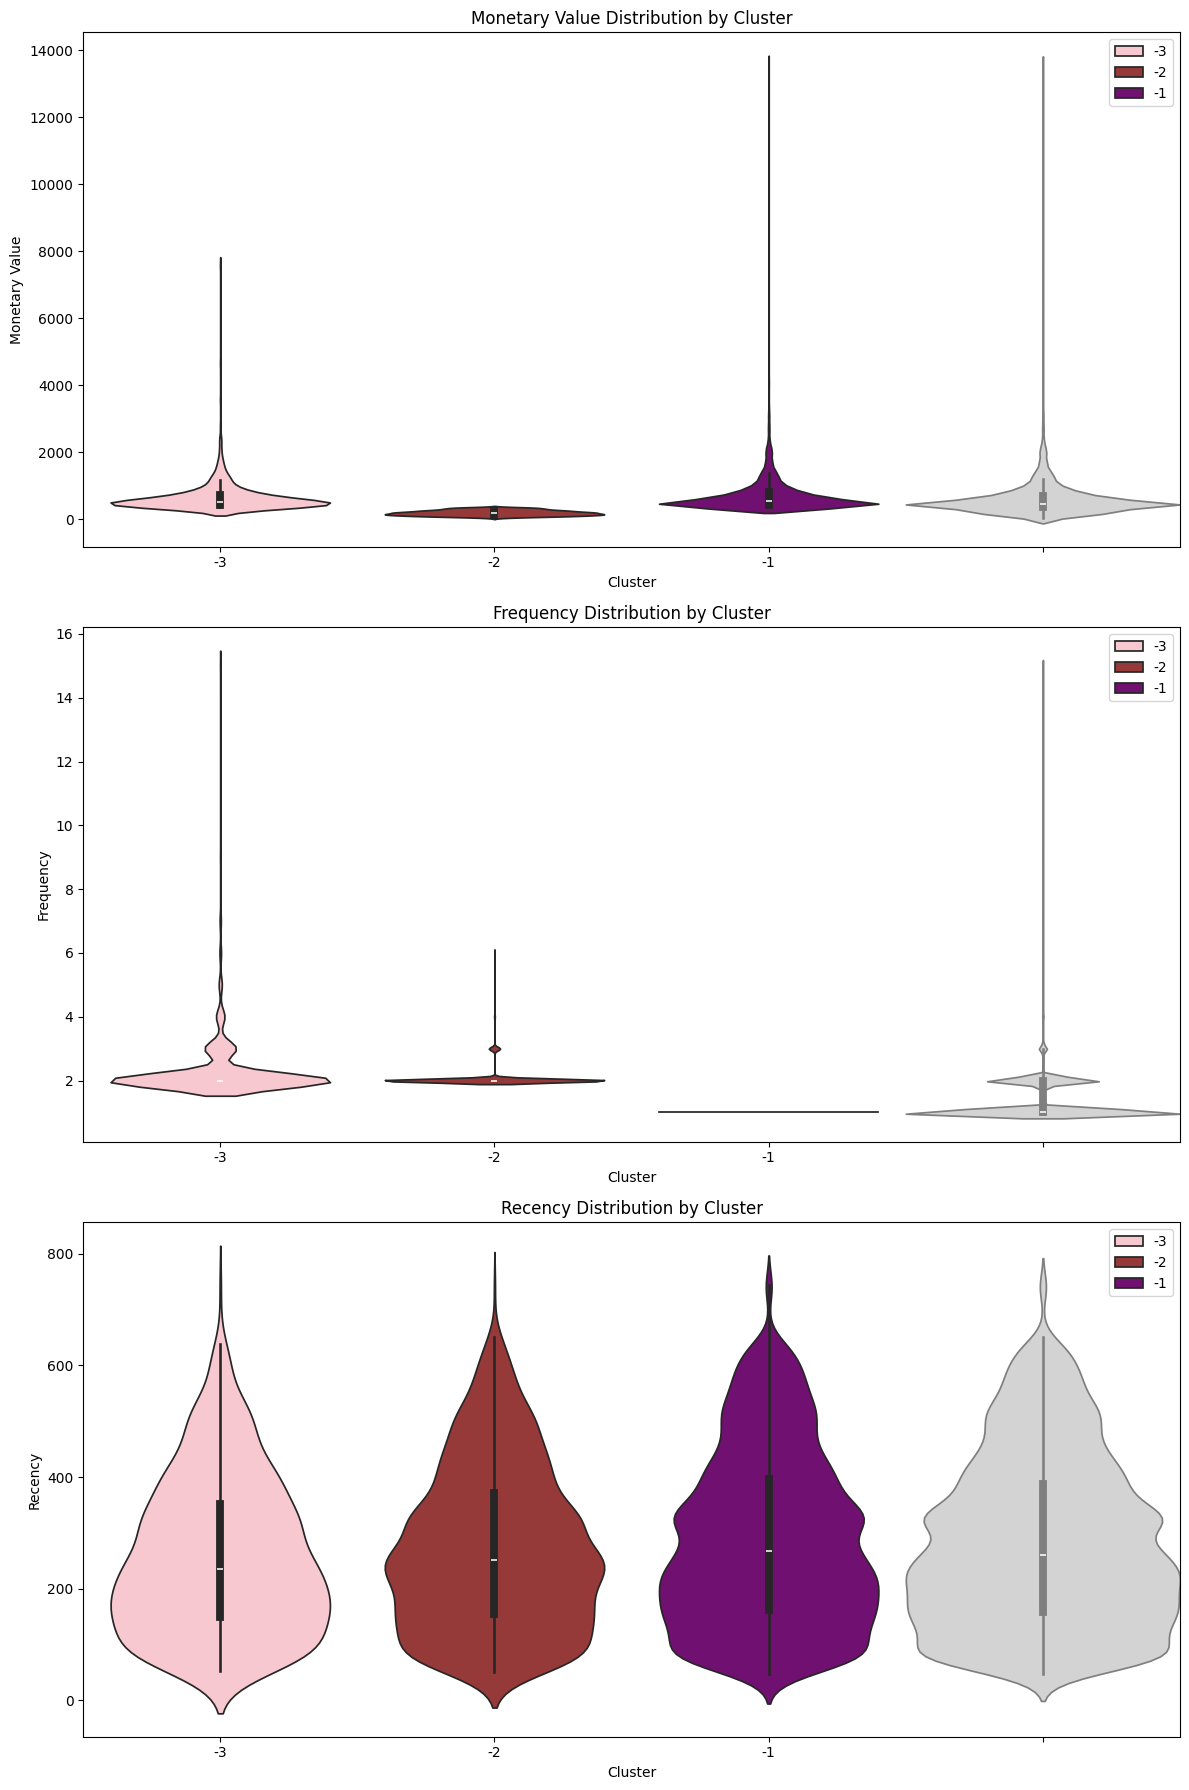

In [29]:
cluster_colors = {
    -3: 'pink',
    -2: 'brown',
    -1: 'purple',
}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df["Cluster"], y=outlier_clusters_df["monetary"], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df["monetary"], color='lightgray', width=1.0) # violinplot tổng thể
plt.title("Monetary Value Distribution by Cluster")
plt.ylabel("Monetary Value")
plt.xlabel("Cluster")

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df["Cluster"], y=outlier_clusters_df["frequency"], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df["frequency"], color='lightgray', width=1.0)
plt.title("Frequency Distribution by Cluster")
plt.ylabel("Frequency")

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df["Cluster"], y=outlier_clusters_df["recency"], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df["recency"], color='lightgray', width=1.0)
plt.title("Recency Distribution by Cluster")
plt.ylabel("Recency")


plt.tight_layout()
plt.show();

#### 🟪 Nhóm -1 (Tím): **BigDeal**
- **Ý nghĩa:**: Khách hàng có giá trị đơn hàng cực cao nhưng mua không thường xuyên, đại diện cho các giao dịch lớn mang tính quyết định.
- **Hành động:**: Chăm sóc chọn lọc và theo dõi sát, ưu tiên xây dựng niềm tin thay vì kích cầu bằng giảm giá.

---

#### 🟤 Nhóm -2 (Nâu): **Valuable**
- **Ý nghĩa:** Khách hàng có tần suất mua khá cao và giá trị chi tiêu vượt trội so với nhóm thông thường, là nguồn doanh thu ổn định. 
- **Hành động:** Giữ chân bằng chương trình khách hàng thân thiết và cá nhân hóa đề xuất để tối đa hóa giá trị vòng đời.  

---

#### 🟥 Nhóm -3 (Hồng nhạt): **Core**
- **Ý nghĩa:** Đây là nhóm khách hàng có tần suất mua sắm cao, giá trị đơn hàng lớn và thời gian mua gần đây dao động từ ngắn đến trung bình. Họ chính là lực lượng tạo ra phần lớn doanh thu cho doanh nghiệp.
- **Hành động:**  
  - Gửi lời cảm ơn, đề xuất sản phẩm liên quan.  
  - Ưu tiên chăm sóc cao nhất với đặc quyền riêng và trải nghiệm vượt trội để duy trì sự trung thành tuyệt đối.

### 5.3 Tổng hợp

#### Gán data

In [30]:
cluster_labels = {
    0: "Nurture",
    1: "Re-Engage",
    2: "Develop",
    -1: "BigDeal",
    -2: "Valuable",
    -3: "Core",
}

full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

cluster_count = full_clustering_df["ClusterLabel"].value_counts()
feature_means = full_clustering_df.groupby("ClusterLabel")[["monetary", "frequency", "recency"]].mean()

#### Biểu đồ phân bố khách hàng sau khi phân cụm

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
feature_means_scaled = pd.DataFrame(
    scaler.fit_transform(feature_means),
    columns=feature_means.columns,
    index=feature_means.index
)

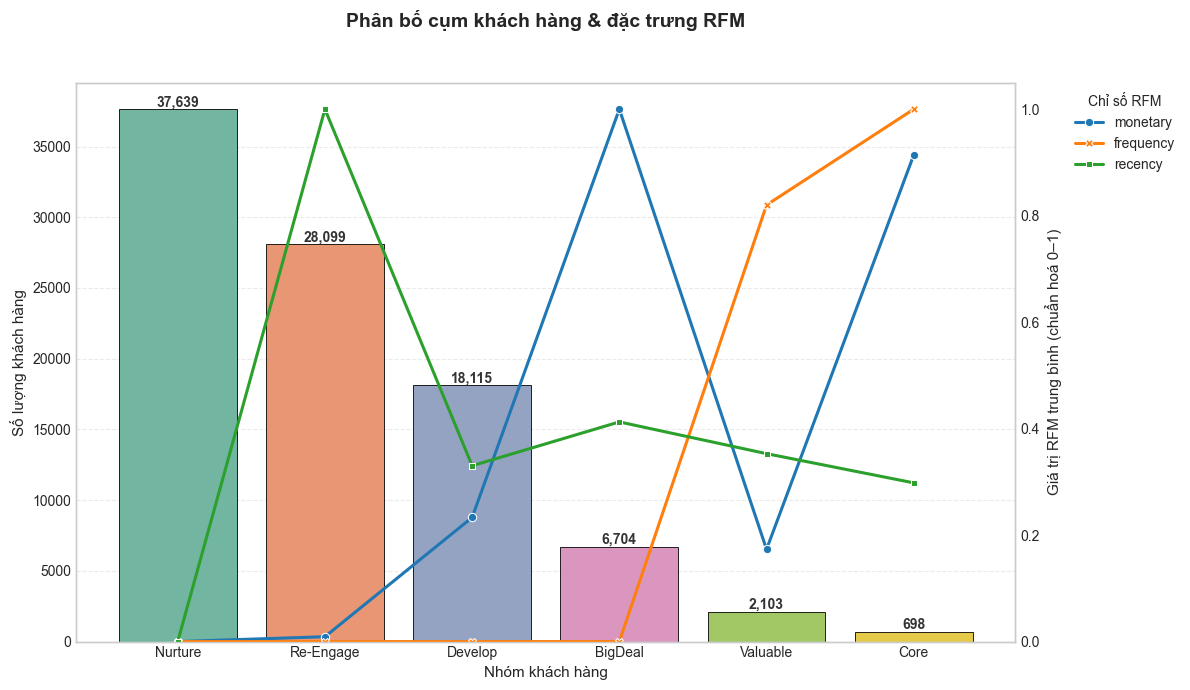

In [32]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 7))

# =========================
# Bar chart: số lượng khách hàng
# =========================
sns.barplot(
    x=cluster_count.index,
    y=cluster_count.values,
    hue=cluster_count.index,
    palette="Set2",
    legend=False,
    edgecolor="black",
    linewidth=0.6,
    ax=ax1
)

ax1.set_xlabel("Nhóm khách hàng", fontsize=11)
ax1.set_ylabel("Số lượng khách hàng", fontsize=11)

ax1.set_title(
    "Phân bố cụm khách hàng & đặc trưng RFM",
    fontsize=14,
    fontweight="bold",
    pad=40
)

# Ghi số lên đầu cột
for i, v in enumerate(cluster_count.values):
    ax1.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Giảm độ đậm grid trục Y (bar)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.grid(axis="x", visible=False)

ax2 = ax1.twinx()

sns.lineplot(
    data=feature_means_scaled,
    markers=True,
    dashes=False,
    linewidth=2.2,
    ax=ax2
)

ax2.set_ylabel("Giá trị RFM trung bình (chuẩn hoá 0–1)", fontsize=11)
ax2.set_ylim(0, 1.05)

ax2.legend(
    title="Chỉ số RFM",
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    frameon=False
)

ax2.grid(False)

plt.tight_layout()
plt.show()

| Cụm           | Ý nghĩa                        | Hành động               |
| ------------- | ---------------------------------------- | --------------------------- |
| **Core**      | Mua thường xuyên – mới mua – giá trị cao | Giữ chân, ưu đãi đặc biệt   |
| **BigDeal**   | Chi nhiều nhưng mua ít                   | Tăng tần suất mua           |
| **Valuable**  | Gần giống Core nhưng yếu hơn             | Đẩy lên Core                |
| **Develop**   | Ở mức trung bình                         | Nuôi dưỡng để nâng F hoặc M |
| **Re-Engage** | Lâu không mua                            | Khuyến mãi kéo lại          |
| **Nurture**   | Khách mới                                | Chăm sóc ban đầu, làm quen  |

____
## 6. Ghi lại dữ liệu

In [33]:
full_clustering_df.to_csv("../data/3_model/clustered_data.csv", index=False)